## Importing the libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import preprocessing as pp
from sklearn import metrics as met 
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import model_selection as ms

## Load and Prepare Data

In [2]:
basedf = pd.read_csv('train.csv')
print(basedf.head(5))
print(f'Info ------------------------------------------------------------------------------')
basedf.info() # A lot of Missing values on cabin were dropping it but getting back on it if model resualts not good enough. name and ticket and passengerid will be dropped. sex and embarked need one hot encoding. and we'll do somthing about that age missing data 

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
In

In [3]:
basedf['Embarked'] = basedf['Embarked'].fillna('S')
basedf['Embarked'].value_counts()
df = basedf.drop(columns = ['PassengerId', 'Cabin' , 'Name', 'Ticket'])
df['Sex'] = df['Sex'].replace({ 'male' : 1 ,
                                'female' : 0 })
df = pd.concat([df, pd.get_dummies(df['Embarked'] , dtype = int)], axis = 1)
df = df.drop(columns = 'Embarked') # Encoding Sex and embarked 
pba1 = df.loc[df['Pclass'] == 1 , 'Age'].median()
pba2 = df.loc[df['Pclass'] == 2 , 'Age'].median()
pba3 = df.loc[df['Pclass'] == 3 , 'Age'].median()
df.loc[df['Pclass'] == 1 , 'Age'] = df.loc[df['Pclass'] == 1 , 'Age'].fillna(pba1)
df.loc[df['Pclass'] == 2 , 'Age'] = df.loc[df['Pclass'] == 2 , 'Age'].fillna(pba2)
df.loc[df['Pclass'] == 3 , 'Age'] = df.loc[df['Pclass'] == 3 , 'Age'].fillna(pba3)
del pba1 , pba2 , pba3 # Filling missing Ages 
df1 = df.copy()
df2 = df.copy()
df1['Familysize'] = df['Parch'] + df['SibSp']
df1 = df1.drop(columns = ['Parch','SibSp'])# Making 2 diffrent data sets for diffrent features to see which works out better ? 
print(df1.head(2))
print(df2.head(2))
print(df.isnull().sum())
print(df.head(2))#one last check and moving on 

   Survived  Pclass Sex   Age     Fare  C  Q  S  Familysize
0         0       3   1  22.0   7.2500  0  0  1           1
1         1       1   0  38.0  71.2833  1  0  0           1
   Survived  Pclass Sex   Age  SibSp  Parch     Fare  C  Q  S
0         0       3   1  22.0      1      0   7.2500  0  0  1
1         1       1   0  38.0      1      0  71.2833  1  0  0
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
C           0
Q           0
S           0
dtype: int64
   Survived  Pclass Sex   Age  SibSp  Parch     Fare  C  Q  S
0         0       3   1  22.0      1      0   7.2500  0  0  1
1         1       1   0  38.0      1      0  71.2833  1  0  0


## EDA

In [4]:
cordf1 = df1.corr()
print(df1.corr()['Survived']['Familysize'])

0.016638989282745178


In [5]:
cordf2 = df2.corr()
print(df2.corr()['Survived'][['SibSp', 'Parch']])
del df2 , df1 # Seems like these 2 work just fine ofc we can add the other one here too but for now its alright 

SibSp   -0.035322
Parch    0.081629
Name: Survived, dtype: float64


## Visualization

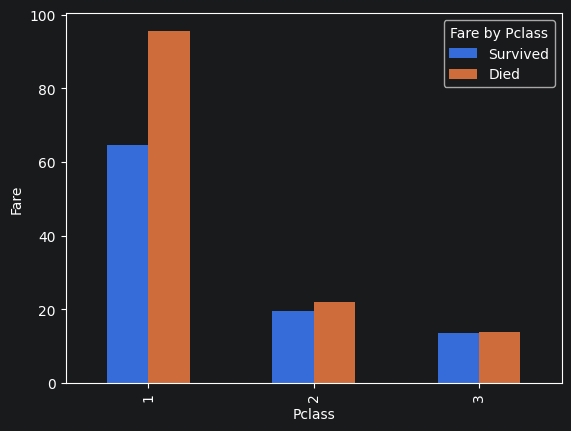

In [6]:
surv_fare_pclass = df.groupby([ df['Pclass'],df['Survived']])['Fare'].mean().unstack()
surv_fare_pclass.plot(kind = 'bar')
plt.xlabel('Pclass')
plt.ylabel('Fare')
plt.legend(title = 'Fare by Pclass' , labels = ['Survived' , 'Died'] )
plt.show() # First class people survived more ofc poor die 

<function matplotlib.pyplot.show(close=None, block=None)>

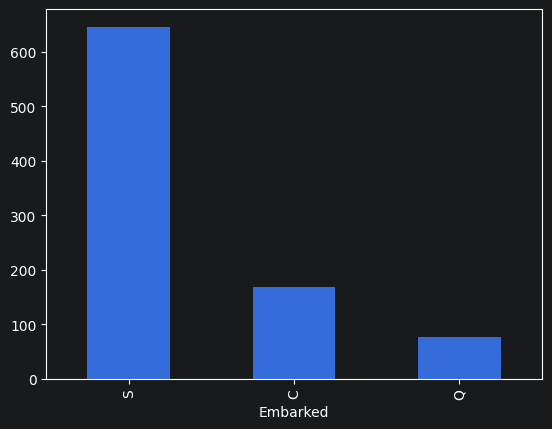

In [7]:
basedf['Embarked'].value_counts().plot(kind='bar')
plt.show #most people embarked from s meaning c and q can give us a good view for that part of the data since its not generalized like s

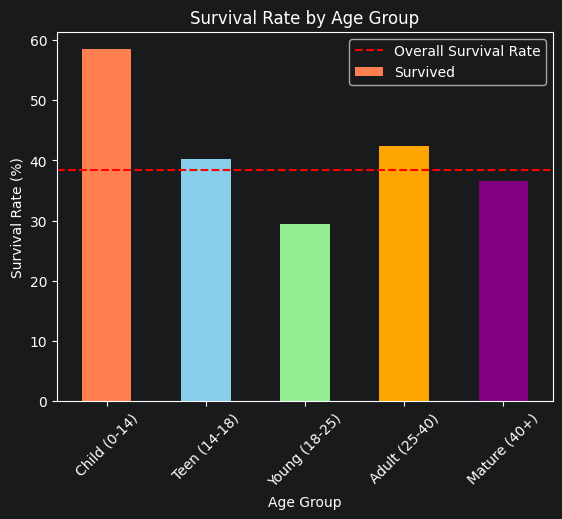

In [8]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 14, 18, 25, 40, 100],
    labels=['Child (0-14)', 'Teen (14-18)', 'Young (18-25)', 'Adult (25-40)', 'Mature (40+)']
)

# Survival rate per age group
age_survival = df.groupby('AgeGroup')['Survived'].mean() * 100

age_survival.plot(kind='bar', color=['coral', 'skyblue', 'lightgreen', 'orange', 'purple'])
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=45)
plt.axhline(y=df['Survived'].mean() * 100, color='red', linestyle='--', label='Overall Survival Rate')
plt.legend()
plt.show()
df = df.drop(columns = 'AgeGroup') # Old and young people have died most they saved kids and adults the most 

<Axes: xlabel='Embarked', ylabel='count'>

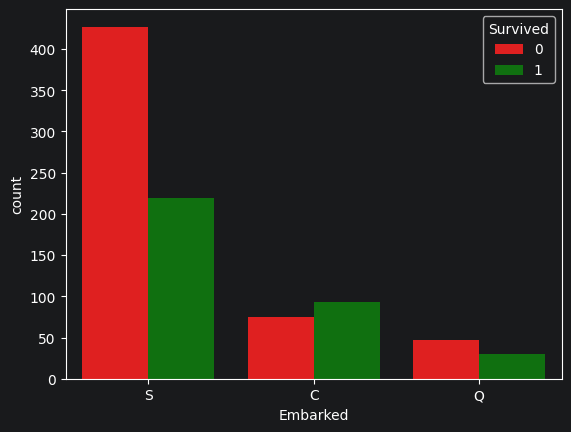

In [9]:
sns.countplot(
    data=basedf, 
    x='Embarked', 
    hue='Survived',
    palette={0: 'red', 1: 'green'}
)
# More survival on people who embarked from c 

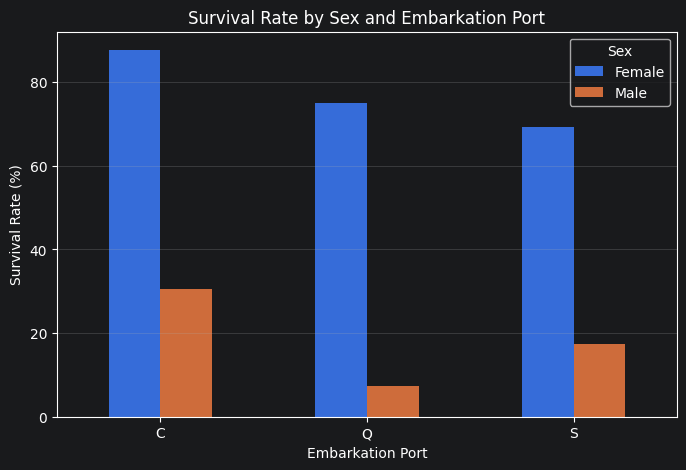

In [10]:

survival_sex_embarked = basedf.groupby(['Embarked', 'Sex'])['Survived'].mean().unstack() * 100

# Plot grouped bars
survival_sex_embarked.plot(kind='bar', figsize=(8, 5))
plt.title('Survival Rate by Sex and Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.legend(['Female', 'Male'], title='Sex')
plt.grid(axis='y', alpha=0.3)
plt.show() # while q had more survival rate but it seems like less than 10% of men from q has survived 

<Axes: xlabel='SibSp', ylabel='count'>

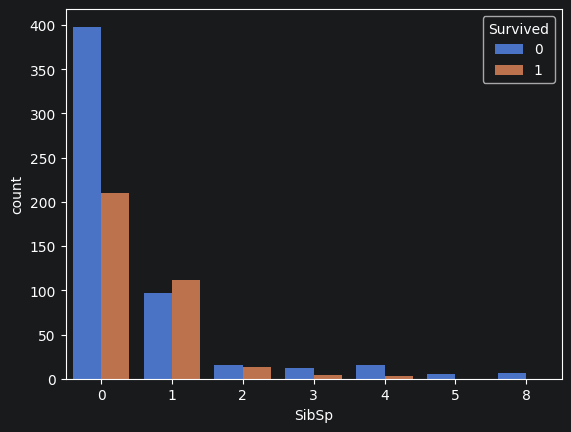

In [11]:
sns.countplot(x='SibSp', hue='Survived',data=basedf) # Survival rate of people with small family are bigger than people who are alone or have big family 

<Axes: xlabel='Parch', ylabel='count'>

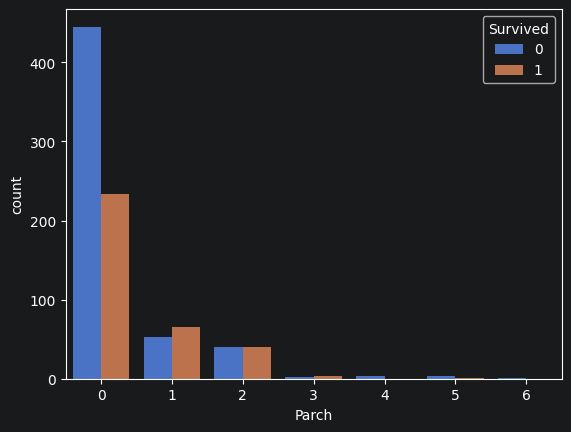

In [12]:
sns.countplot(x='Parch', hue='Survived',data=basedf)# same as last one 

<Axes: xlabel='Survived', ylabel='Fare'>

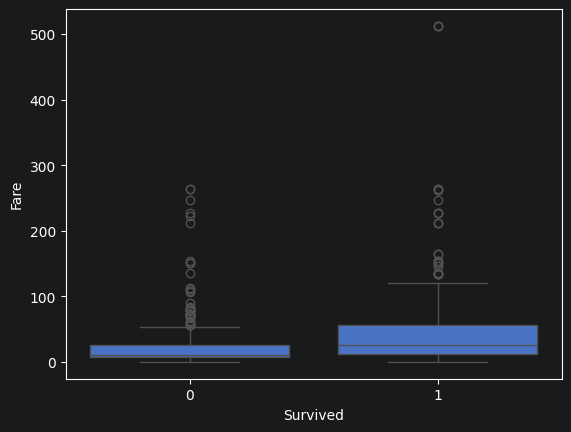

In [13]:
sns.boxplot(x='Survived', y='Fare', data=basedf)# see people who payed more survived more

## Learning Models 

In [14]:
X = df.iloc[:,1:]
X
y = df.iloc[:,0]
y
X_train, X_test, y_train, y_test = train_test_split(X , y ,test_size = 0.2 , random_state = 10) 
X_trainmm = X_train.copy()
X_testmm = X_test.copy()
X_train = X_train.astype(float)
X_test = X_test.astype(float)
X_trainmm = X_trainmm.astype(float)
X_testmm = X_testmm.astype(float)

In [15]:
mm = pp.MinMaxScaler() # i was just seeing whats the diffrence between thses two 
X_trainmm.iloc[:,:6] = mm.fit_transform(X_train.iloc[:,:6])
X_testmm.iloc[:,:6] = mm.transform(X_test.iloc[:,:6])
X_trainmm
X_testmm
del X_trainmm , X_testmm
sc = pp.StandardScaler() # Probably only use this 
X_train.iloc[:,:6] = sc.fit_transform(X_train.iloc[:,:6])
X_test.iloc[:,:6] = sc.transform(X_test.iloc[:,:6])
X_train
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,C,Q,S
590,0.825233,0.753845,0.452333,-0.458505,-0.477849,-0.498623,0.0,0.0,1.0
131,0.825233,0.753845,-0.683484,-0.458505,-0.477849,-0.500081,0.0,0.0,1.0
628,0.825233,0.753845,-0.229157,-0.458505,-0.477849,-0.483640,0.0,0.0,1.0
195,-1.577900,-1.326533,2.193918,-0.458505,-0.477849,2.210950,1.0,0.0,0.0
230,-1.577900,-1.326533,0.452333,0.412044,-0.477849,0.985467,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
456,-1.577900,0.753845,2.723966,-0.458505,-0.477849,-0.121040,0.0,0.0,1.0
191,-0.376333,0.753845,-0.759205,-0.458505,-0.477849,-0.384425,0.0,0.0,1.0
603,0.825233,0.753845,1.133823,-0.458505,-0.477849,-0.480643,0.0,0.0,1.0
94,0.825233,0.753845,2.269639,-0.458505,-0.477849,-0.496193,0.0,0.0,1.0


In [16]:
lr = LogisticRegression()
lr.fit(X_train , y_train)
lrpred = lr.predict(X_test)
lrpred
y_train

57     0
717    1
431    1
633    0
163    0
      ..
369    1
320    0
527    0
125    1
265    0
Name: Survived, Length: 712, dtype: int64

In [17]:
#ConfusionMatrixDisplay #precision_score #mean_squared_error #mean_absolute_error #f1_score #confusion_matrix #accuracy_score just a list of metrics i wanted to use
print(f'Accuracy : {met.accuracy_score(y_test , lrpred )}')
print(f'F1 : {met.f1_score(y_test , lrpred )}')
print(f'Precision Score : {met.precision_score(y_test , lrpred )}')
print(f'Recall Score : {met.recall_score(y_test , lrpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , lrpred )}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , lrpred )}')
cv_lr_score = ms.cross_val_score(estimator = lr ,X = X_train , y = y_train , cv = 5)
cv_lr_score

Accuracy : 0.8156424581005587
F1 : 0.736
Precision Score : 0.7301587301587301
Recall Score : 0.7419354838709677
ROC AUC Score : 0.7983181692859112
Confusion Matrix :
 [[100  17]
 [ 16  46]]


array([0.7972028 , 0.82517483, 0.73943662, 0.8028169 , 0.80985915])

In [18]:
rc = RidgeClassifier()
rc.fit(X_train , y_train)
rcpred = rc.predict(X_test)

In [19]:
print(f'Accuracy : {met.accuracy_score(y_test , rcpred )}')
print(f'F1 : {met.f1_score(y_test , rcpred )}')
print(f'Precision Score : {met.precision_score(y_test , rcpred )}')
print(f'Recall Score : {met.recall_score(y_test , rcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , rcpred )}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , rcpred )}')
cv_rc_score = ms.cross_val_score(estimator = rc ,X = X_train , y = y_train , cv = 5)
cv_rc_score

Accuracy : 0.8156424581005587
F1 : 0.7317073170731707
Precision Score : 0.7377049180327869
Recall Score : 0.7258064516129032
ROC AUC Score : 0.7945271574303833
Confusion Matrix :
 [[101  16]
 [ 17  45]]


array([0.76923077, 0.83916084, 0.71830986, 0.78873239, 0.81690141])

In [20]:
dt = DecisionTreeClassifier()
dt.fit(X_train , y_train)
dtpred = dt.predict(X_test)

In [21]:
print(f'Accuracy : {met.accuracy_score(y_test , dtpred )}')
print(f'F1 : {met.f1_score(y_test , dtpred )}')
print(f'Precision Score : {met.precision_score(y_test , dtpred )}')
print(f'Recall Score : {met.recall_score(y_test , dtpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , dtpred )}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , dtpred )}')
cv_dt_score = ms.cross_val_score(estimator = dt ,X = X_train , y = y_train , cv = 5)
cv_dt_score

Accuracy : 0.8044692737430168
F1 : 0.7368421052631579
Precision Score : 0.6901408450704225
Recall Score : 0.7903225806451613
ROC AUC Score : 0.8011441963054866
Confusion Matrix :
 [[95 22]
 [13 49]]


array([0.74125874, 0.82517483, 0.70422535, 0.78169014, 0.76056338])

In [22]:
svc = SVC()
svc.fit(X_train , y_train)
svcpred = svc.predict(X_test)

In [23]:
print(f'Accuracy : {met.accuracy_score(y_test , svcpred )}')
print(f'F1 : {met.f1_score(y_test , svcpred )}')
print(f'Precision Score : {met.precision_score(y_test , svcpred )}')
print(f'Recall Score : {met.recall_score(y_test , svcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , svcpred )}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , svcpred )}')
cv_svc_score = ms.cross_val_score(estimator = svc ,X = X_train , y = y_train , cv = 5)
cv_svc_score

Accuracy : 0.8379888268156425
F1 : 0.7603305785123967
Precision Score : 0.7796610169491526
Recall Score : 0.7419354838709677
ROC AUC Score : 0.8154121863799283
Confusion Matrix :
 [[104  13]
 [ 16  46]]


array([0.81118881, 0.83916084, 0.77464789, 0.82394366, 0.84507042])

In [24]:
knn = KNeighborsClassifier()
knn.fit(X_train , y_train)
knnpred = knn.predict(X_test)

In [25]:
print(f'Accuracy : {met.accuracy_score(y_test , knnpred )}')
print(f'F1 : {met.f1_score(y_test , knnpred )}')
print(f'Precision Score : {met.precision_score(y_test , knnpred )}')
print(f'Recall Score : {met.recall_score(y_test , knnpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , knnpred )}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , knnpred )}')
cv_knn_score = ms.cross_val_score(estimator = knn ,X = X_train , y = y_train , cv = 5)
cv_knn_score

Accuracy : 0.8268156424581006
F1 : 0.7479674796747967
Precision Score : 0.7540983606557377
Recall Score : 0.7419354838709677
ROC AUC Score : 0.8068651778329198
Confusion Matrix :
 [[102  15]
 [ 16  46]]


array([0.81818182, 0.7972028 , 0.72535211, 0.81690141, 0.82394366])

In [26]:
abc = AdaBoostClassifier()
abc.fit(X_train , y_train)
abcpred = abc.predict(X_test)

In [27]:
print(f'Accuracy : {met.accuracy_score(y_test , abcpred )}')
print(f'F1 : {met.f1_score(y_test , abcpred )}')
print(f'Precision Score : {met.precision_score(y_test , abcpred )}')
print(f'Recall Score : {met.recall_score(y_test , abcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , abcpred )}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , abcpred )}')
cv_abc_score = ms.cross_val_score(estimator = abc ,X = X_train , y = y_train , cv = 5)
cv_abc_score

Accuracy : 0.8268156424581006
F1 : 0.7559055118110236
Precision Score : 0.7384615384615385
Recall Score : 0.7741935483870968
ROC AUC Score : 0.8144472015439757
Confusion Matrix :
 [[100  17]
 [ 14  48]]


array([0.78321678, 0.82517483, 0.74647887, 0.79577465, 0.83802817])

In [28]:
bc = BaggingClassifier()
bc.fit(X_train , y_train)
bcpred = bc.predict(X_test)

In [29]:
print(f'Accuracy : {met.accuracy_score(y_test , bcpred )}')
print(f'F1 : {met.f1_score(y_test , bcpred )}')
print(f'Precision Score : {met.precision_score(y_test , bcpred )}')
print(f'Recall Score : {met.recall_score(y_test , bcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , bcpred )}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , bcpred )}')
cv_bc_score = ms.cross_val_score(estimator = bc ,X = X_train , y = y_train , cv = 5)
cv_bc_score

Accuracy : 0.8100558659217877
F1 : 0.734375
Precision Score : 0.7121212121212122
Recall Score : 0.7580645161290323
ROC AUC Score : 0.797835676867935
Confusion Matrix :
 [[98 19]
 [15 47]]


array([0.8041958 , 0.83916084, 0.71126761, 0.8028169 , 0.76760563])

In [30]:
rfc = RandomForestClassifier()
rfc.fit(X_train , y_train)
rfcpred = rfc.predict(X_test)

In [31]:
print(f'Accuracy : {met.accuracy_score(y_test , rfcpred )}')
print(f'F1 : {met.f1_score(y_test , rfcpred )}')
print(f'Precision Score : {met.precision_score(y_test , rfcpred )}')
print(f'Recall Score : {met.recall_score(y_test , rfcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , rfcpred )}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , rfcpred )}')
cv_rfc_score = ms.cross_val_score(estimator = rfc ,X = X_train , y = y_train , cv = 5)
cv_rfc_score

Accuracy : 0.8100558659217877
F1 : 0.7301587301587301
Precision Score : 0.71875
Recall Score : 0.7419354838709677
ROC AUC Score : 0.7940446650124069
Confusion Matrix :
 [[99 18]
 [16 46]]


array([0.78321678, 0.79020979, 0.73239437, 0.81690141, 0.79577465])

In [32]:
xg = xgb.XGBRFClassifier()
xg.fit(X_train , y_train)
xgcpred = xg.predict(X_test)

In [33]:
print(f'Accuracy : {met.accuracy_score(y_test , xgcpred )}')
print(f'F1 : {met.f1_score(y_test , xgcpred )}')
print(f'Precision Score : {met.precision_score(y_test , xgcpred )}')
print(f'Recall Score : {met.recall_score(y_test , xgcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , xgcpred )}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , xgcpred )}')
cv_xgc_score = ms.cross_val_score(estimator = xg ,X = X_train , y = y_train , cv = 5)
cv_xgc_score

Accuracy : 0.8268156424581006
F1 : 0.7479674796747967
Precision Score : 0.7540983606557377
Recall Score : 0.7419354838709677
ROC AUC Score : 0.8068651778329198
Confusion Matrix :
 [[102  15]
 [ 16  46]]


array([0.81118881, 0.85314685, 0.77464789, 0.85211268, 0.83098592])

##  Re Data Preprocessing

In [34]:
df['Title'] = basedf['Name'].str.extract(r',\s([^\.]+)\.')
df['Title'] = df['Title'].replace(['Dr','Rev','Mlle','Major','Col','the Countess',
                                   'Capt','Ms','Sir','Lady','Mme','Don','Jonkheer'], 'Others')
df['Deck'] = basedf['Cabin'].str[0].fillna('U')
 #others are mostly ships crew nope they are diffrent stupid names for woman mostly

In [35]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,C,Q,S,Title,Deck
0,0,3,1,22.0,1,0,7.2500,0,0,1,Mr,U
1,1,1,0,38.0,1,0,71.2833,1,0,0,Mrs,C
2,1,3,0,26.0,0,0,7.9250,0,0,1,Miss,U
3,1,1,0,35.0,1,0,53.1000,0,0,1,Mrs,C
4,0,3,1,35.0,0,0,8.0500,0,0,1,Mr,U
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,0,0,1,Others,U
887,1,1,0,19.0,0,0,30.0000,0,0,1,Miss,B
888,0,3,0,24.0,1,2,23.4500,0,0,1,Miss,U
889,1,1,1,26.0,0,0,30.0000,1,0,0,Mr,C


In [36]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'C', 'Q',
       'S', 'Title', 'Deck'],
      dtype='str')

## ReVisualization

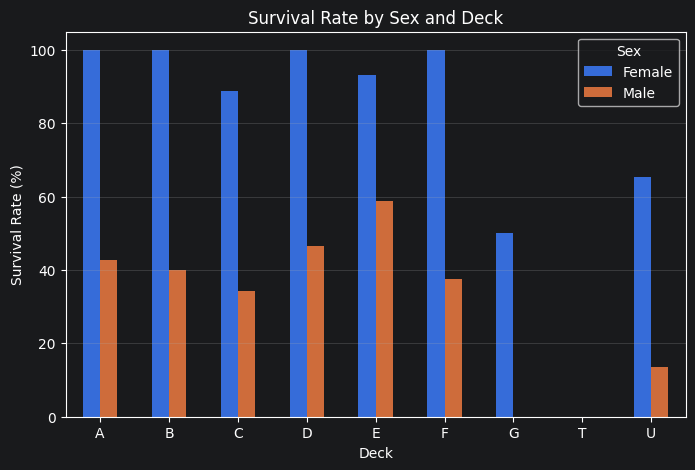

In [37]:
survival_deck_sex = df.groupby(['Deck', 'Sex'])['Survived'].mean().unstack() * 100

# Plot grouped bars
survival_deck_sex.plot(kind='bar', figsize=(8, 5))
plt.title('Survival Rate by Sex and Deck')
plt.xlabel('Deck')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.legend(['Female', 'Male'], title='Sex')
plt.grid(axis='y', alpha=0.3)
plt.show()

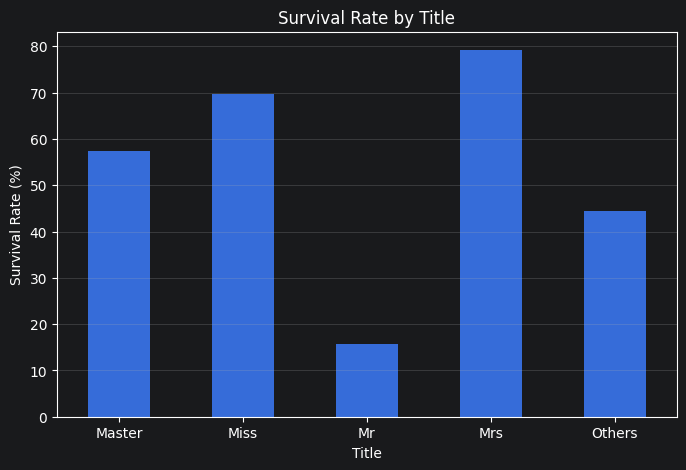

In [38]:
survival_deck_sex = df.groupby(['Title'])['Survived'].mean() * 100

# Plot grouped bars
survival_deck_sex.plot(kind='bar', figsize=(8, 5))
plt.title('Survival Rate by Title')
plt.xlabel('Title')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

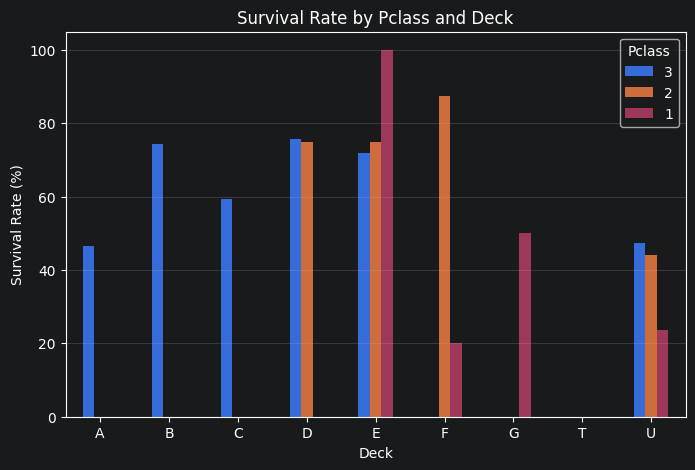

In [39]:
survival_deck_sex = df.groupby(['Deck', 'Pclass'])['Survived'].mean().unstack() * 100

# Plot grouped bars
survival_deck_sex.plot(kind='bar', figsize=(8, 5))
plt.title('Survival Rate by Pclass and Deck')
plt.xlabel('Deck')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.legend(['3', '2' , '1'], title='Pclass')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [40]:
df = pd.get_dummies(df, columns=['Title', 'Deck'], dtype=int)

## ReModeling With New Columns

In [41]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'C', 'Q',
       'S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Others', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E',
       'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U'],
      dtype='str')

In [42]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [43]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,C,Q,S,Title_Master,...,Title_Others,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
0,3,1,22.0,1,0,7.2500,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,1,0,38.0,1,0,71.2833,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,3,0,26.0,0,0,7.9250,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,35.0,1,0,53.1000,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,3,1,35.0,0,0,8.0500,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
887,1,0,19.0,0,0,30.0000,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
888,3,0,24.0,1,2,23.4500,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
889,1,1,26.0,0,0,30.0000,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [44]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [45]:
X = df.drop(columns='Survived')   
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
scale_cols = ['Age', 'Fare', 'SibSp', 'Parch']

In [68]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
scaler = pp.StandardScaler()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])
xg = xgb.XGBRFClassifier()
xg.fit(X_train, y_train)
xgcpred = xg.predict(X_test)

In [69]:
print(f'Accuracy : {met.accuracy_score(y_test , xgcpred )}')
print(f'F1 : {met.f1_score(y_test , xgcpred )}')
print(f'Precision Score : {met.precision_score(y_test , xgcpred )}')
print(f'Recall Score : {met.recall_score(y_test , xgcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , xgcpred )}')
cv_xg_score = ms.cross_val_score(estimator = xg ,X = X_train_scaled , y = y_train , cv = 5)
print(f'Cross-Validation :{cv_xg_score}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , xgcpred )}')

parameters = { 
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'learning_rate' : [0.01 , 0.25 , 0.5 , 0.75 , 1],
    'subsample' : [0.5 , 0.75 , 1],
    'colsample_bytree' : [0.5 , 0.75 , 1],
    'gamma' : [0 , 0.5 , 1 , 2 , 4 , 6 , 9],
    'min_child_weight' : [0 , 0.5 , 1 , 2 , 5 , 8 , 10]
}
grid = ms.GridSearchCV(
    estimator=xg,        
    param_grid=parameters,  
    cv=5,                   
    scoring='accuracy',     
    n_jobs=-1               
)
grid.fit(X_train_scaled , y_train)
print(grid.best_score_)     
print(grid.best_params_)    
print(grid.best_estimator_) 

predictions = grid.predict(X_test_scaled)

Accuracy : 0.8435754189944135
F1 : 0.7741935483870968
Precision Score : 0.7741935483870968
Recall Score : 0.7741935483870968
ROC AUC Score : 0.8272677143644885
Cross-Validation :[0.84615385 0.82517483 0.76760563 0.85915493 0.83802817]
Confusion Matrix :
 [[103  14]
 [ 14  48]]
0.8454939426770413
{'colsample_bytree': 0.5, 'gamma': 0, 'learning_rate': 0.75, 'max_depth': 20, 'min_child_weight': 0, 'n_estimators': 500, 'subsample': 1}
XGBRFClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bytree=0.5, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=0, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.75, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=20, max_leaves=None,
    

In [51]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)
sc = pp.StandardScaler() # Probably only use this also somtimes has a big ass red error about incomapatible dtype but it disapear when i run it again 
X_train.iloc[:,:6] = sc.fit_transform(X_train.iloc[:,:6])
X_test.iloc[:,:6] = sc.transform(X_test.iloc[:,:6])

In [52]:
lr = LogisticRegression()
lr.fit(X_train , y_train)
lrpred = lr.predict(X_test)

In [53]:
print(f'Accuracy : {met.accuracy_score(y_test , lrpred )}')
print(f'F1 : {met.f1_score(y_test , lrpred )}')
print(f'Precision Score : {met.precision_score(y_test , lrpred )}')
print(f'Recall Score : {met.recall_score(y_test , lrpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , lrpred )}')
cv_lr_score = ms.cross_val_score(estimator = lr ,X = X_train , y = y_train , cv = 5)
print(f'Cross-Validation :{cv_lr_score}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , lrpred )}')
parameters = { 
     'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
grid = ms.GridSearchCV(
    estimator=lr,        
    param_grid=parameters,  
    cv=5,                   
    scoring='accuracy',     
    n_jobs=-1               
)
grid.fit(X_train , y_train)
print(grid.best_score_)     
print(grid.best_params_)    
print(grid.best_estimator_) 

predictions = grid.predict(X_test)

Accuracy : 0.8435754189944135
F1 : 0.7777777777777778
Precision Score : 0.765625
Recall Score : 0.7903225806451613
ROC AUC Score : 0.8310587262200165
Cross-Validation :[0.83216783 0.85314685 0.78169014 0.82394366 0.82394366]
Confusion Matrix :
 [[102  15]
 [ 13  49]]
0.8243967300305328
{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
LogisticRegression(C=10, penalty='l2', solver='liblinear')


H:\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [54]:
rc = RidgeClassifier()
rc.fit(X_train , y_train)
rcpred = rc.predict(X_test)

In [55]:
print(f'Accuracy : {met.accuracy_score(y_test , rcpred )}')
print(f'F1 : {met.f1_score(y_test , rcpred )}')
print(f'Precision Score : {met.precision_score(y_test , rcpred )}')
print(f'Recall Score : {met.recall_score(y_test , rcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , rcpred )}')
cv_rc_score = ms.cross_val_score(estimator = rc ,X = X_train , y = y_train , cv = 5)
print(f'Cross-Validation :{cv_rc_score}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , rcpred )}')
parameters = { 
    #'C': [0.01, 0.1, 1, 10, 100],
    'alpha': [ 0.01 , 0.1 , 0.5 , 1 , 2 , 5 , 10 ],
    #'gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
}
grid = ms.GridSearchCV(
    estimator=rc,        
    param_grid=parameters,  
    cv=5,                   
    scoring='accuracy',     
    n_jobs=-1               
)
grid.fit(X_train , y_train)
print(grid.best_score_)     
print(grid.best_params_)    
print(grid.best_estimator_) 

predictions = grid.predict(X_test)

Accuracy : 0.8491620111731844
F1 : 0.7804878048780488
Precision Score : 0.7868852459016393
Recall Score : 0.7741935483870968
ROC AUC Score : 0.8315412186379927
Cross-Validation :[0.83916084 0.85314685 0.77464789 0.83098592 0.83098592]
Confusion Matrix :
 [[104  13]
 [ 14  48]]
0.8271939328277357
{'alpha': 0.1}
RidgeClassifier(alpha=0.1)


In [56]:
dt = DecisionTreeClassifier()
dt.fit(X_train , y_train)
dtpred = dt.predict(X_test)

In [57]:
print(f'Accuracy : {met.accuracy_score(y_test , dtpred )}')
print(f'F1 : {met.f1_score(y_test , dtpred )}')
print(f'Precision Score : {met.precision_score(y_test , dtpred )}')
print(f'Recall Score : {met.recall_score(y_test , dtpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , dtpred )}')
cv_dt_score = ms.cross_val_score(estimator = dt ,X = X_train , y = y_train , cv = 5)
print(f'Cross-Validation :{cv_dt_score}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , dtpred )}')
parameters = { 
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid = ms.GridSearchCV(
    estimator=dt,        
    param_grid=parameters,  
    cv=5,                   
    scoring='accuracy',     
    n_jobs=-1               
)
grid.fit(X_train , y_train)
print(grid.best_score_)     
print(grid.best_params_)    
print(grid.best_estimator_) 

predictions = grid.predict(X_test)

Accuracy : 0.7877094972067039
F1 : 0.7076923076923077
Precision Score : 0.6764705882352942
Recall Score : 0.7419354838709677
ROC AUC Score : 0.7769506479183899
Cross-Validation :[0.74825175 0.75524476 0.71830986 0.78873239 0.73943662]
Confusion Matrix :
 [[95 22]
 [16 46]]
0.8188220230473752
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=5)


In [58]:
svc = SVC()
svc.fit(X_train , y_train)
svcpred = svc.predict(X_test)

In [59]:
print(f'Accuracy : {met.accuracy_score(y_test , svcpred )}')
print(f'F1 : {met.f1_score(y_test , svcpred )}')
print(f'Precision Score : {met.precision_score(y_test , svcpred )}')
print(f'Recall Score : {met.recall_score(y_test , svcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , svcpred )}')
cv_svc_score = ms.cross_val_score(estimator = svc ,X = X_train , y = y_train , cv = 5)
print(f'Cross-Validation :{cv_svc_score}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , svcpred )}')
parameters = [{'C': [0.25, 0.5, 0.75, 1],
              'kernel': ['linear']},
             {'C': [0.25, 0.5, 0.75, 1], 
              'kernel': ['rbf'], 
              'gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
             }]
grid = ms.GridSearchCV(
    estimator=svc,        
    param_grid=parameters,  
    cv=5,                   
    scoring='accuracy',     
    n_jobs=-1               
)
grid.fit(X_train , y_train)
print(grid.best_score_)     
print(grid.best_params_)    
print(grid.best_estimator_) 

predictions = grid.predict(X_test)

Accuracy : 0.8491620111731844
F1 : 0.773109243697479
Precision Score : 0.8070175438596491
Recall Score : 0.7419354838709677
ROC AUC Score : 0.8239591949269369
Cross-Validation :[0.83216783 0.85314685 0.78873239 0.83098592 0.83098592]
Confusion Matrix :
 [[106  11]
 [ 16  46]]
0.8314192849404117
{'C': 0.75, 'gamma': 0.1, 'kernel': 'rbf'}
SVC(C=0.75, gamma=0.1)


In [60]:
knn = KNeighborsClassifier()
knn.fit(X_train , y_train)
knnpred = knn.predict(X_test)

In [61]:
print(f'Accuracy : {met.accuracy_score(y_test , knnpred )}')
print(f'F1 : {met.f1_score(y_test , knnpred )}')
print(f'Precision Score : {met.precision_score(y_test , knnpred )}')
print(f'Recall Score : {met.recall_score(y_test , knnpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , knnpred )}')
cv_knn_score = ms.cross_val_score(estimator = knn ,X = X_train , y = y_train , cv = 5)
print(f'Cross-Validation :{cv_knn_score}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , knnpred )}')
parameters = {'n_neighbors': [3, 5, 7, 9, 11, 15],
             'weights': ['uniform', 'distance'],
             'metric': ['euclidean', 'manhattan']}
grid = ms.GridSearchCV(
    estimator=knn,        
    param_grid=parameters,  
    cv=5,                   
    scoring='accuracy',     
    n_jobs=-1               
)
grid.fit(X_train , y_train)
print(grid.best_score_)     
print(grid.best_params_)    
print(grid.best_estimator_) 

predictions = grid.predict(X_test)

Accuracy : 0.8491620111731844
F1 : 0.7804878048780488
Precision Score : 0.7868852459016393
Recall Score : 0.7741935483870968
ROC AUC Score : 0.8315412186379927
Cross-Validation :[0.83916084 0.83216783 0.74647887 0.84507042 0.81690141]
Confusion Matrix :
 [[104  13]
 [ 14  48]]
0.8257756328178862
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
KNeighborsClassifier(metric='manhattan', n_neighbors=3)


In [62]:
abc = AdaBoostClassifier()
abc.fit(X_train , y_train)
abcpred = abc.predict(X_test)

In [63]:
print(f'Accuracy : {met.accuracy_score(y_test , abcpred )}')
print(f'F1 : {met.f1_score(y_test , abcpred )}')
print(f'Precision Score : {met.precision_score(y_test , abcpred )}')
print(f'Recall Score : {met.recall_score(y_test , abcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , abcpred )}')
cv_abc_score = ms.cross_val_score(estimator = abc ,X = X_train , y = y_train , cv = 5)
print(f'Cross-Validation :{cv_abc_score}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , abcpred )}')
parameters = {'n_estimators': [50, 100, 300, 500,],
             'learning_rate': [0.1,0.25,0.5,0.75,1]
             }
grid = ms.GridSearchCV(
    estimator=abc,        
    param_grid=parameters,  
    cv=5,                   
    scoring='accuracy',     
    n_jobs=-1               
)
grid.fit(X_train , y_train)
print(grid.best_score_)     
print(grid.best_params_)    
print(grid.best_estimator_) 

predictions = grid.predict(X_test)

Accuracy : 0.8435754189944135
F1 : 0.7741935483870968
Precision Score : 0.7741935483870968
Recall Score : 0.7741935483870968
ROC AUC Score : 0.8272677143644885
Cross-Validation :[0.8041958  0.81818182 0.75352113 0.80985915 0.83098592]
Confusion Matrix :
 [[103  14]
 [ 14  48]]
0.8244065793361568
{'learning_rate': 1, 'n_estimators': 500}
AdaBoostClassifier(learning_rate=1, n_estimators=500)


In [64]:
bc = BaggingClassifier()
bc.fit(X_train , y_train)
bcpred = bc.predict(X_test)

In [65]:
print(f'Accuracy : {met.accuracy_score(y_test , bcpred )}')
print(f'F1 : {met.f1_score(y_test , bcpred )}')
print(f'Precision Score : {met.precision_score(y_test , bcpred )}')
print(f'Recall Score : {met.recall_score(y_test , bcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , bcpred )}')
cv_bc_score = ms.cross_val_score(estimator = bc ,X = X_train , y = y_train , cv = 5)
print(f'Cross-Validation :{cv_bc_score}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , bcpred )}')
parameters = {'n_estimators': [50, 100, 300, 500,],
              'max_samples': [1,2,5,8,10]
             }
grid = ms.GridSearchCV(
    estimator=bc,        
    param_grid=parameters,  
    cv=5,                   
    scoring='accuracy',     
    n_jobs=-1               
)
grid.fit(X_train , y_train)
print(grid.best_score_)     
print(grid.best_params_)    
print(grid.best_estimator_) 

predictions = grid.predict(X_test)

Accuracy : 0.8435754189944135
F1 : 0.7741935483870968
Precision Score : 0.7741935483870968
Recall Score : 0.7741935483870968
ROC AUC Score : 0.8272677143644885
Cross-Validation :[0.77622378 0.83916084 0.74647887 0.85211268 0.78873239]
Confusion Matrix :
 [[103  14]
 [ 14  48]]
0.7794740470796808
{'max_samples': 10, 'n_estimators': 500}
BaggingClassifier(max_samples=10, n_estimators=500)


In [66]:
rfc = RandomForestClassifier()
rfc.fit(X_train , y_train)
rfcpred = rfc.predict(X_test)

In [67]:
print(f'Accuracy : {met.accuracy_score(y_test , rfcpred )}')
print(f'F1 : {met.f1_score(y_test , rfcpred )}')
print(f'Precision Score : {met.precision_score(y_test , rfcpred )}')
print(f'Recall Score : {met.recall_score(y_test , rfcpred )}')
print(f'ROC AUC Score : {met.roc_auc_score(y_test , rfcpred )}')
cv_rfc_score = ms.cross_val_score(estimator = rfc ,X = X_train , y = y_train , cv = 5)
print(f'Cross-Validation :{cv_rfc_score}')
print(f'Confusion Matrix :\n {met.confusion_matrix(y_test , rfcpred )}')
parameters = {'n_estimators': [50, 100, 300, 500,],
              'criterion': ['gini', 'entropy', 'log_loss'],
              'min_samples_split' : [2,5,8,10],
              'min_samples_leaf' : [1,2,3,4,5],
              'min_weight_fraction_leaf' : [0.1,0.2,0.3,0.4,0.5]
             }
grid = ms.GridSearchCV(
    estimator=rfc,        
    param_grid=parameters,  
    cv=5,                   
    scoring='accuracy',     
    n_jobs=-1               
)
grid.fit(X_train , y_train)
print(grid.best_score_)     
print(grid.best_params_)    
print(grid.best_estimator_) 

predictions = grid.predict(X_test)

Accuracy : 0.8324022346368715
F1 : 0.7619047619047619
Precision Score : 0.75
Recall Score : 0.7741935483870968
ROC AUC Score : 0.8187207058174801
Cross-Validation :[0.81118881 0.81118881 0.76056338 0.84507042 0.77464789]
Confusion Matrix :
 [[101  16]
 [ 14  48]]
0.7836993991923569
{'criterion': 'gini', 'min_samples_leaf': 4, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.1, 'n_estimators': 300}
RandomForestClassifier(min_samples_leaf=4, min_weight_fraction_leaf=0.1,
                       n_estimators=300)
